# 01 — Exploratory Data Analysis
## Olist E-Commerce Customer Churn Prediction
**Goal**: Understand the dataset structure, data quality, and customer behavior patterns before any modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load all datasets
orders = pd.read_csv('../data/olist_orders_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
order_payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
sellers = pd.read_csv('../data/olist_sellers_dataset.csv')
geolocation = pd.read_csv('../data/olist_geolocation_dataset.csv')
category_translation = pd.read_csv('../data/product_category_name_translation.csv')

# Quick sanity check
datasets = {
    'orders': orders,
    'customers': customers,
    'order_items': order_items,
    'order_payments': order_payments,
    'order_reviews': order_reviews,
    'products': products,
    'sellers': sellers,
    'geolocation': geolocation,
    'category_translation': category_translation
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]} columns")

orders: 99,441 rows × 8 columns
customers: 99,441 rows × 5 columns
order_items: 112,650 rows × 7 columns
order_payments: 103,886 rows × 5 columns
order_reviews: 99,224 rows × 7 columns
products: 32,951 rows × 9 columns
sellers: 3,095 rows × 4 columns
geolocation: 1,000,163 rows × 5 columns
category_translation: 71 rows × 2 columns


In [2]:
# Check date columns and convert them
date_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Overview of orders
print("Order Status Distribution ")
print(orders['order_status'].value_counts())
print(f"\nDate range: {orders['order_purchase_timestamp'].min()} → {orders['order_purchase_timestamp'].max()}")

print("\nMissing values per Tables ")
for name, df in datasets.items():
    missing = df.isnull().sum().sum()
    if missing > 0:
        print(f"{name}: {missing} missing values")

Order Status Distribution 
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Date range: 2016-09-04 21:15:19 → 2018-10-17 17:30:18

Missing values per Tables 
orders: 4908 missing values
order_reviews: 145903 missing values
products: 2448 missing values


In [3]:
# Filter to delivered orders only
delivered = orders[orders['order_status'] == 'delivered'].copy()

# Merge with customers
df = delivered.merge(customers, on='customer_id', how='left')

# How many unique customers?
print("Total unique customers:", df['customer_unique_id'].nunique())

# How many orders per customer?
order_counts = df.groupby('customer_unique_id')['order_id'].count()
print("\nOrders per customer")
print(order_counts.value_counts().head(10))

Total unique customers: 93358

Orders per customer
order_id
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64


## Dataset Overview

There are 9 tables in total. The main ones I'll be working with are orders (99,441 rows), customers (99,441 rows), order_items (112,650 rows), order_payments (103,886 rows), and order_reviews (99,224 rows). Supporting tables include products (32,951 rows), sellers (3,095 rows), and geolocation (1,000,163 rows).

The data covers September 2016 to October 2018 — about 2 years of real transactions.

## Data Quality

97% of orders are delivered so I filtered to delivered orders only — cancelled and unavailable orders don't reflect real customer behavior.

Three tables had missing values worth noting. In orders, delivery dates were missing for non-delivered orders which is not a concern after filtering. In order_reviews, most customers simply didn't leave a comment so the missing comment fields are expected. In products, some category names and dimensions were missing and will be handled during feature engineering.

## Churn Definition

93,358 unique customers placed orders and 90,557 of them (97%) bought exactly once. Because almost nobody returns, traditional churn modeling doesn't apply cleanly here. I'm framing this instead as a next purchase prediction problem — a customer is labeled churned if they didn't make a second purchase within 6 months of their first order.

In [4]:
# Get each customer's first and last order date
customer_orders = df.groupby('customer_unique_id').agg(
    first_order=('order_purchase_timestamp', 'min'),
    last_order=('order_purchase_timestamp', 'max'),
    total_orders=('order_id', 'count')
).reset_index()

# Define churn: only one purchase OR gap between first and last > 6 months without returning
cutoff_date = delivered['order_purchase_timestamp'].max() - pd.DateOffset(months=6)

# Only label customers whose first order was before the cutoff
# so they had enough time to potentially return
labeled = customer_orders[customer_orders['first_order'] <= cutoff_date].copy()

# Churned = bought only once
labeled['churned'] = (labeled['total_orders'] == 1).astype(int)

print("Customers available for labeling:", len(labeled))
print("\nChurn distribution")
print(labeled['churned'].value_counts())
print(f"\nChurn rate: {labeled['churned'].mean():.1%}")

Customers available for labeling: 55364

Churn distribution
churned
1    53161
0     2203
Name: count, dtype: int64

Churn rate: 96.0%


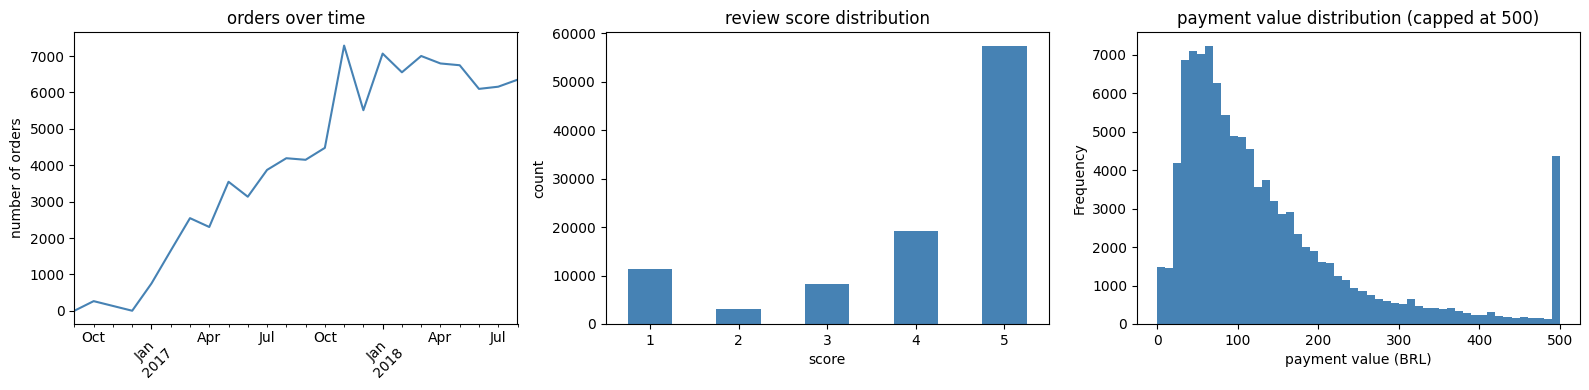

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# orders over time
delivered['month'] = delivered['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = delivered.groupby('month').size()
monthly_orders.plot(ax=axes[0], color='steelblue')
axes[0].set_title('orders over time')
axes[0].set_xlabel('')
axes[0].set_ylabel('number of orders')
axes[0].tick_params(axis='x', rotation=45)

# order review scores
review_counts = order_reviews['review_score'].value_counts().sort_index()
review_counts.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('review score distribution')
axes[1].set_xlabel('score')
axes[1].set_ylabel('count')
axes[1].tick_params(axis='x', rotation=0)

# payment values
order_payments['payment_value'].clip(upper=500).plot(
    kind='hist', bins=50, ax=axes[2], color='steelblue'
)
axes[2].set_title('payment value distribution (capped at 500)')
axes[2].set_xlabel('payment value (BRL)')

plt.tight_layout()
plt.savefig('../data/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

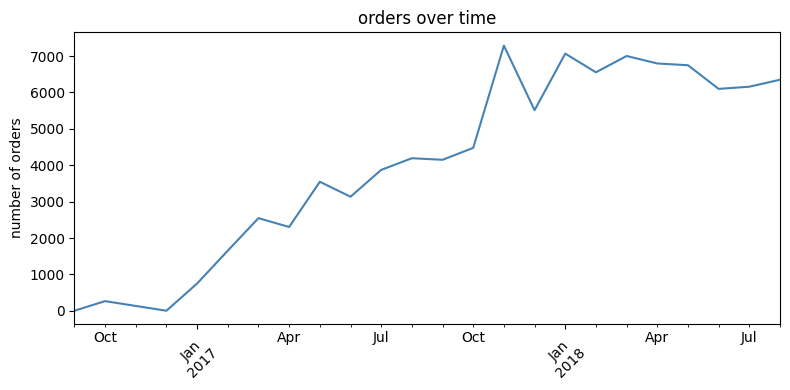

saved orders_over_time.png


In [6]:
delivered['month'] = delivered['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = delivered.groupby('month').size()

fig, ax = plt.subplots(figsize=(8, 4))
monthly_orders.plot(ax=ax, color='steelblue')
ax.set_title('orders over time')
ax.set_xlabel('')
ax.set_ylabel('number of orders')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../data/orders_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved orders_over_time.png")

## EDA Findings

Orders grew steadily from late 2016 through mid 2018, confirming this is real commercial data with organic growth patterns.

Review scores follow a J-shaped distribution — 5 stars is by far the most common, but 1 star is the second most common. Customers who bother leaving a review tend to be either very happy or very unhappy.

Payment values are right-skewed with most orders under 200 BRL. A log transformation will be applied during feature engineering to handle the long tail.

These patterns are consistent with what you'd expect from a real marketplace like Shopee or Lazada.